In [2]:
import numpy as np
from scipy.linalg import block_diag
np.set_printoptions(legacy='1.13',linewidth=np.inf,threshold=np.inf)
import matplotlib.pyplot as plt

In [10]:
def energy_projector(total_dim, energy_indices):
    """
    Creates a projector onto energy subspaces

    Parameters:
    total_dim: Total dimension of the system
    energy_indices: List of indices corresponding to the energy subspace

    Returns:
    Projector matrix P_E
    """
    projector = np.zeros((total_dim, total_dim))
    for i in energy_indices:
        projector[i, i] = 1.0
    return projector

# Total dimension of your system
#total_dim = AA.shape[0] + BB.shape[0] + CC.shape[0]# (6+9+3)
total_dim = 33

# Define energy levels based on your block structure
# For example, let's say:
# E=1 corresponds to the first block (AA)
# E=2 corresponds to the second block (BB)
# E=3 corresponds to the third block (CC)

# Indices for each energy subspace
E_S1_indices = (range(0,6),range(6,15),range(21,30))
E_S2_indices = (range(15,21),range(30,33))

# 예시: E=0.5 상태 |psi_0.5> 와 E=1.5 상태 |psi_1.5> 의 중첩
# (실제 |psi> 벡터는 H_RS의 고유벡터여야 함)
#psi_0_5_vector = np.zeros(total_dim, dtype=complex)
#psi_0_5_vector[0] = 1.0 # E=0.5 고유벡터 중 하나라고 가정

#psi_1_5_vector = np.zeros(total_dim, dtype=complex)
#psi_1_5_vector[6] = 1.0 # E=1.5 고유벡터 중 하나라고 가정

# 중첩 상태 벡터
#psi_superposition = (psi_0_5_vector + psi_1_5_vector) / np.sqrt(2)

#Arbitrary Random matrix
psi_superposition = np.random.rand(total_dim)
psi_superposition /= np.linalg.norm(psi_superposition)

# 중첩 상태 밀도 행렬 (이제 비대각 블록이 생김)
rho_RS_with_coherence = np.outer(psi_superposition, np.conj(psi_superposition))

In [11]:
#Define the projectors corresponding eash system subblocks
for i in range(0,2,1):
  for j in range(0,3,1):
    if i == 0:
      globals()['deltaS{}E{}'.format(i,j)] = energy_projector(total_dim, E_S1_indices[j])
    if i == 1:
      try:
        globals()['deltaS{}E{}'.format(i,j)] = energy_projector(total_dim, E_S2_indices[j])
      except:
        None

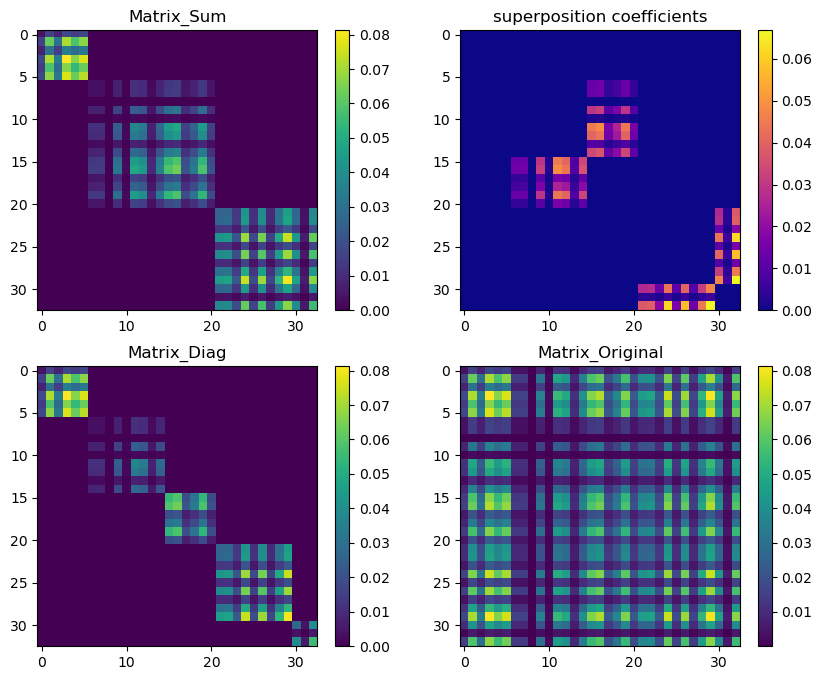

In [31]:
# 이제 이 rho_RS_with_coherence를 사용하여 계산
# test : case of projection in from (E2,S1) to (E1,S1)
#P_E1_rho_P_E2 = P_E2 @ rho_RS_with_coherence @ P_E1
P_E1_rho_P_E2 = deltaS0E2 @ rho_RS_with_coherence @ deltaS1E1
P_E1_rho_P_E2 += deltaS0E1 @ rho_RS_with_coherence @ deltaS1E0
P_E1_rho_P_E2 += deltaS1E1 @ rho_RS_with_coherence @ deltaS0E2
P_E1_rho_P_E2 += deltaS1E0 @ rho_RS_with_coherence @ deltaS0E1
# P_E1_rho_P_E2 는 이제 0이 아닐 수 있습니다.

#Check the total projected space recovered into original state (guess, delta = 1)
Matrix_Sum = np.zeros((33,33))
Matrix_diag = np.zeros((33,33))

for i in range(0,2,1):
  for j in range(0,3,1):
    try:
      #Matrix_Sum += globals()['deltaS{}E{}'.format(i,j)] @ rho_RS_with_coherence @ globals()['deltaS{}E{}'.format(i+1,j)]
      Matrix_diag += globals()['deltaS{}E{}'.format(i,j)] @ rho_RS_with_coherence @ globals()['deltaS{}E{}'.format(i,j)]
    except:
      None

Matrix_Sum += (P_E1_rho_P_E2 + Matrix_diag)

plt.figure(figsize=(10, 8))

plt.subplot(222)
plt.imshow(np.abs(P_E1_rho_P_E2),cmap='plasma')
plt.title("superposition coefficients")
plt.colorbar()

plt.subplot(221)
plt.imshow(np.abs(Matrix_Sum))
plt.title("Matrix_Sum")
plt.colorbar()

plt.subplot(223)
plt.imshow(np.abs(Matrix_diag))
plt.title("Matrix_Diag")
plt.colorbar()


plt.subplot(224)
plt.imshow(np.abs(rho_RS_with_coherence))
plt.title("Matrix_Original")
plt.colorbar()

plt.show()
#아오 어디가 잘못된거야 하...